Dataset Shape: (50000, 21)


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,0.0,1,0,62.3,6.57,40.6,65.7,No,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,0.0,2,0,44.0,5.86,40.3,51.8,No,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2.0,2,1,73.8,7.50,73.6,67.9,No,1,0
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,5.0,6,2,100.0,9.41,98.7,NaN,No,1,0
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,NaN,4,2,90.8,9.24,83.1,100.0,No,1,0



Columns in dataset:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']

Features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']

Target distribution:
PlacementStatus
0    26251
1    23749
Name: count, dtype: int64

After Encoding:
Number of features: 33

Training data: (40000, 33)
Testing data : (10000, 33)

Model training completed!

========== RESULTS ==========
Binary Logistic Regression Accuracy: 0.7898

Confusion Matrix:
[[4228 1022]
 [1080 3670]]

Classificati

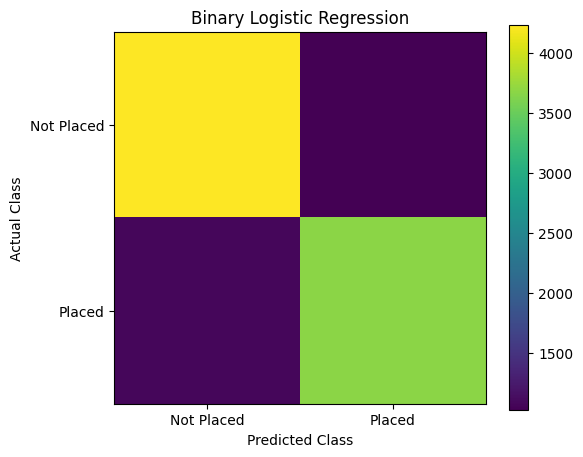

In [7]:
# ============================================================
# LOGISTIC REGRESSION - BINARY CLASSIFICATION
# PlacementPredict Dataset
# ============================================================

# Install / import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. Load your PlacementPredict dataset
# ============================================================

df = pd.read_csv("placement_predict_50k_adjusted.csv")

print("Dataset Shape:", df.shape)

display(df.head())

# ============================================================
# 2. Check columns
# ============================================================

print("\nColumns in dataset:")
print(df.columns.tolist())

# ============================================================
# 3. Target
# ============================================================

# PlacementStatus is the target
y = df["PlacementStatus"]

# Remove target and ID/anomaly columns
remove_columns = ["PlacementStatus"]

if "IsAnomaly" in df.columns:
    remove_columns.append("IsAnomaly")

X = df.drop(columns=remove_columns)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

# ============================================================
# 4. Handle categorical columns
# ============================================================

# Convert categorical columns to numerical using one-hot encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

# Replace missing values
X = X.fillna(X.median(numeric_only=True))

# If any remaining missing values exist
X = X.fillna(0)

print("\nAfter Encoding:")
print("Number of features:", X.shape[1])

# ============================================================
# 5. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)

# ============================================================
# 6. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 7. Create Logistic Regression Model
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ============================================================
# 8. Train Model
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)

print("\nModel training completed!")

# ============================================================
# 9. Prediction
# ============================================================

y_pred = model.predict(X_test_scaled)

# ============================================================
# 10. Accuracy
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========== RESULTS ==========")

print(
    "Binary Logistic Regression Accuracy:",
    round(accuracy, 4)
)

# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

# ============================================================
# 12. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# 13. Confusion Matrix Plot
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Binary Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.show()